In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor  

from sklearn.model_selection import train_test_split  
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error  
from sklearn import tree 

In [2]:
df = pd.read_csv("drug200.csv")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [3]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [4]:
df.duplicated().sum()

0

In [5]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [6]:
# df['Na_to_K'] = df['Na_to_K'].astype(int)

In [7]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [8]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [9]:
df.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [10]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [12]:
df.shape

(200, 6)

In [13]:
df_sex = df['Sex'].value_counts()

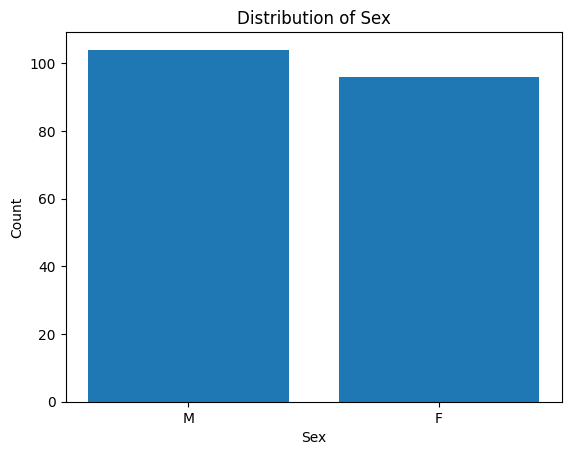

In [14]:
plt.bar(df_sex.index , df_sex.values)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Sex')
plt.show()

In [15]:
df_drug = df['Drug'].value_counts()
df_drug

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

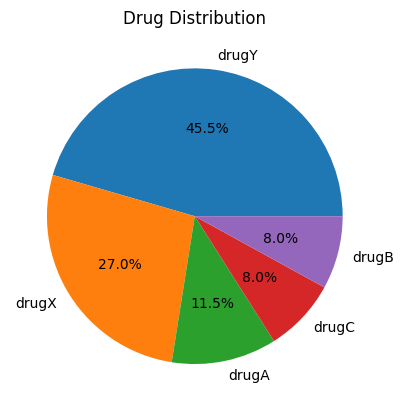

In [16]:
plt.pie(df_drug.values, labels=df_drug.index, autopct='%1.1f%%')
plt.title("Drug Distribution")
plt.show()

In [17]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [18]:
df['Sex'] = df['Sex'].map({'M':1,'F':0})
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,HIGH,HIGH,25.355,drugY
1,47,1,LOW,HIGH,13.093,drugC
2,47,1,LOW,HIGH,10.114,drugC
3,28,0,NORMAL,HIGH,7.798,drugX
4,61,0,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,0,LOW,HIGH,11.567,drugC
196,16,1,LOW,HIGH,12.006,drugC
197,52,1,NORMAL,HIGH,9.894,drugX
198,23,1,NORMAL,NORMAL,14.020,drugX


In [19]:
df['BP'] = df['BP'].map({'NORMAL':0,'HIGH':1,'LOW':2})
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,1,HIGH,25.355,drugY
1,47,1,2,HIGH,13.093,drugC
2,47,1,2,HIGH,10.114,drugC
3,28,0,0,HIGH,7.798,drugX
4,61,0,2,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,0,2,HIGH,11.567,drugC
196,16,1,2,HIGH,12.006,drugC
197,52,1,0,HIGH,9.894,drugX
198,23,1,0,NORMAL,14.020,drugX


In [20]:
df['Cholesterol'] = df['Cholesterol'].map({'HIGH':1,'NORMAL':0})
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,1,1,25.355,drugY
1,47,1,2,1,13.093,drugC
2,47,1,2,1,10.114,drugC
3,28,0,0,1,7.798,drugX
4,61,0,2,1,18.043,drugY
...,...,...,...,...,...,...
195,56,0,2,1,11.567,drugC
196,16,1,2,1,12.006,drugC
197,52,1,0,1,9.894,drugX
198,23,1,0,0,14.020,drugX


In [21]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,1,1,25.355,drugY
1,47,1,2,1,13.093,drugC
2,47,1,2,1,10.114,drugC
3,28,0,0,1,7.798,drugX
4,61,0,2,1,18.043,drugY
...,...,...,...,...,...,...
195,56,0,2,1,11.567,drugC
196,16,1,2,1,12.006,drugC
197,52,1,0,1,9.894,drugX
198,23,1,0,0,14.020,drugX


In [22]:
print(df['Sex'].value_counts())
print(df['BP'].value_counts())
print(df['Cholesterol'].value_counts())

Sex
1    104
0     96
Name: count, dtype: int64
BP
1    77
2    64
0    59
Name: count, dtype: int64
Cholesterol
1    103
0     97
Name: count, dtype: int64


In [23]:
X = df[["Age","Sex","BP","Cholesterol","Na_to_K"]]
y = df["Drug"]

In [24]:
X_train , x_test , y_train , y_test = train_test_split(X,y , test_size = 0.2, random_state = 42)

In [60]:
dtree = DecisionTreeClassifier(criterion='gini' , max_depth=3,random_state=42)
dtree.fit(X_train , y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [68]:
y_pred = dtree.predict(x_test)

array(['drugX', 'drugY', 'drugX', 'drugX', 'drugY', 'drugY', 'drugY',
       'drugX', 'drugA', 'drugX', 'drugA', 'drugX', 'drugY', 'drugA',
       'drugA', 'drugY', 'drugA', 'drugX', 'drugX', 'drugY', 'drugA',
       'drugX', 'drugX', 'drugY', 'drugY', 'drugY', 'drugX', 'drugX',
       'drugY', 'drugX', 'drugY', 'drugX', 'drugX', 'drugY', 'drugA',
       'drugY', 'drugX', 'drugA', 'drugY', 'drugA'], dtype=object)

In [70]:
accuracy_score(y_test,y_pred)

0.8

In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix
confusion_matrix(y_test,y_pred)

array([[ 6,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]], dtype=int64)